In [1]:
%matplotlib widget

from stellar_explorer import StellarExplorer
from stellar_explorer import ScatterDataset


In [10]:
Starlist = pd.read_csv("../GAP_classification_wip_4.csv")
base_cut = (Starlist['comments']=='none')*((Starlist['parallax_error']/Starlist['parallax'])<0.1)*(Starlist['M_mag']>-1)*(Starlist['fidelity_v2']>0.75)*(Starlist['eb']!=1)*(Starlist['eb_prsa']!=1)*(Starlist['pipeline']!='QLP')
puls     = (Starlist['ds']==1)*base_cut

DFP      = Starlist[puls].reset_index(drop=True)
DFP_hads = DFP[DFP['HADS']==1]

DFP_subset = DFP[:20]


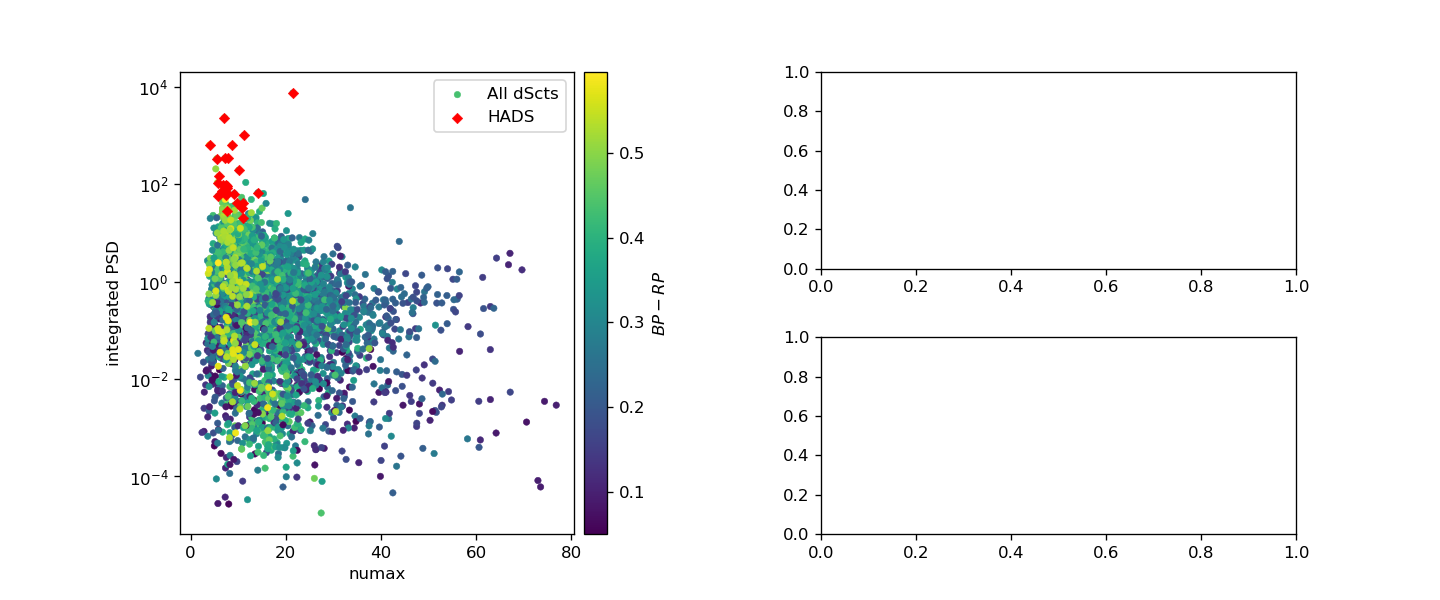

In [4]:
explorer = StellarExplorer(
    catalog_df        = DFP,
    lightcurve_dir    = "../GAP/LK",
    powerspectrum_dir = "../GAP/PS",
)

dataset1 = ScatterDataset(
    x     = DFP["centroid_power_above_5med_fb_shift"].values,
    y     = DFP["new_PSD"].values,
    ids   = DFP["tess"].values,
    color = DFP.bp_rp.values,
    cmap  = "viridis",
    show_colorbar  = True,
    colorbar_label = r"$BP - RP$",
    label          = "All dScts",
    picker         = 15
)

dataset2 = ScatterDataset(
    x    = DFP_hads["centroid_power_above_5med_fb_shift"].values,
    y    = DFP_hads["new_PSD"].values,
    ids  = DFP_hads["tess"].values,
    label  = "HADS",
    color  = 'red',
    marker = 'D', 
    size   = 20
)

explorer.show(
    datasets = [dataset1, dataset2],
    xlabel   = "numax",
    ylabel   = "integrated PSD", 
    yscale   = 'log', 
#     ylim     = (1.2*DFP.M_mag.max(), 1.5*DFP.M_mag.min())
)

/Users/prasadmani/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/projects2/stellar-explorer/stellar_explorer/explorer.py:118: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  artist = self.ax_scatter.scatter(


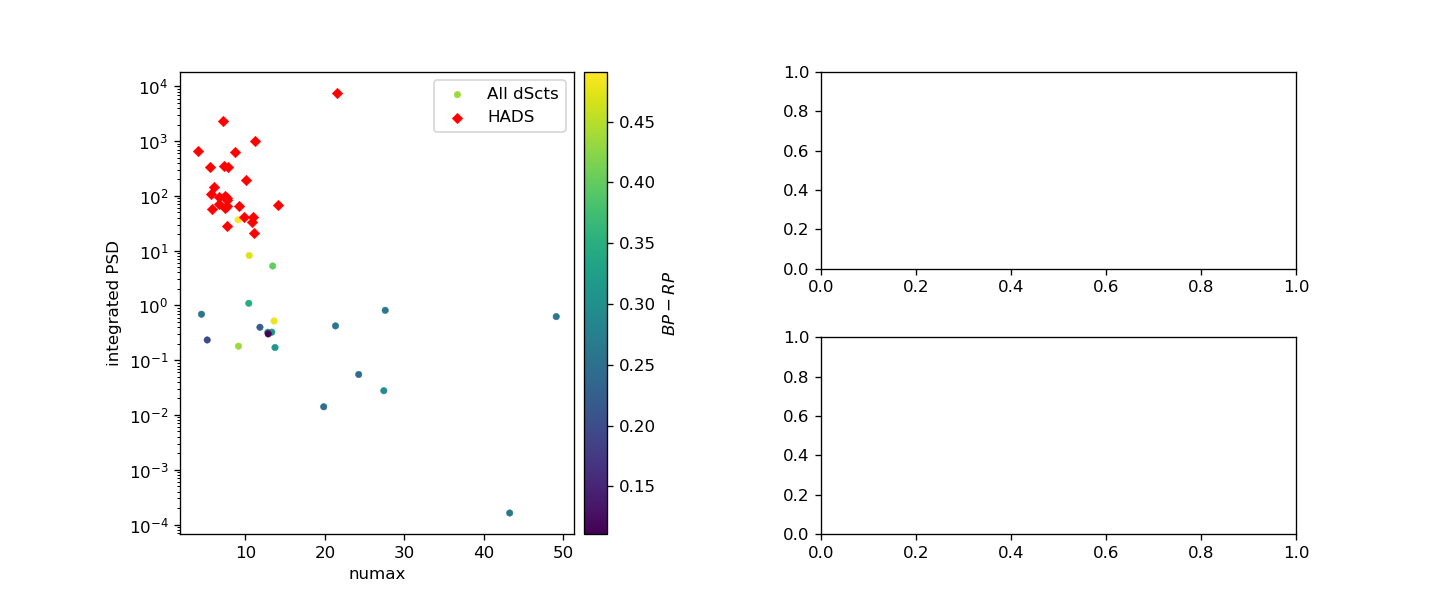

In [11]:
explorer = StellarExplorer(
    catalog_df        = DFP,
    lightcurve_dir    = "../GAP/LK",
    powerspectrum_dir = "../GAP/PS",
)

dataset1 = ScatterDataset(
    x     = DFP_subset["centroid_power_above_5med_fb_shift"].values,
    y     = DFP_subset["new_PSD"].values,
    ids   = DFP_subset["tess"].values,
    color = DFP_subset.bp_rp.values,
    cmap  = "viridis",
    show_colorbar  = True,
    colorbar_label = r"$BP - RP$",
    label          = "All dScts",
    picker         = 15
)

dataset2 = ScatterDataset(
    x    = DFP_hads["centroid_power_above_5med_fb_shift"].values,
    y    = DFP_hads["new_PSD"].values,
    ids  = DFP_hads["tess"].values,
    label  = "HADS",
    color  = 'red',
    marker = 'D', 
    size   = 20
)

explorer.show(
    datasets = [dataset1, dataset2],
    xlabel   = "numax",
    ylabel   = "integrated PSD", 
    yscale   = 'log', 
#     ylim     = (1.2*DFP.M_mag.max(), 1.5*DFP.M_mag.min())
)

In [23]:
# import shutil, os

# # os.makedirs('sample_data/LK', exist_ok=True)
# for item in subset_fnames:
#     shutil.copy(f'../GAP/LK/{item}', 'sample_data/LK/')
#     shutil.copy(f'../GAP/PS/{item}', 'sample_data/PS/')

In [29]:
demo_dataframe = pd.concat((DFP_subset, DFP_hads)).reset_index(drop=True)

In [30]:
demo_dataframe.to_csv('demo_dataframe.csv', index=False)